# Check Training Pipeline

These are some of the ways to verify that the training pipeline is working as expected. 

In [1]:
from pathlib import Path
import random
import numpy as np
from typing import Tuple

import requests
from zipfile import ZipFile, BadZipFile

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

## System Config

In [2]:
def seed_everything(seed_value: int = 42):
    random.seed(seed_value)
    np.random.seed(seed=seed_value)
    torch.manual_seed(seed=seed_value)
    torch.cuda.manual_seed_all(seed=seed_value)
    torch.mps.manual_seed(seed=seed_value)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
def get_default_device() -> Tuple[torch.device, bool]:
    is_gpu_available = torch.cuda.is_available()
    return torch.device("cuda" if is_gpu_available else "cpu"), is_gpu_available

In [4]:
seed_everything(seed_value=0)
DEVICE, IS_GPU_AVAILABLE = get_default_device()

## Download Dataset

In [5]:
ROOT = Path().resolve()
print(ROOT)

/Users/tapasyagutta/workspace/deep-learning/deep-learning-projects/basics/check_training_pipeline


In [6]:
def download_file(url: str, save_path: Path):
    response = requests.get(url=url, stream=True)
    with open(save_path, "wb") as file:
        for chunk in response.iter_content(chunk_size=1024):
            if chunk:
                file.write(chunk)

    print(f"Downloaded: {save_path}")


def unzip(zip_file_path: Path = None):
    try:
        with ZipFile(zip_file_path, "r") as z:
            z.extractall("./")
            print(f"Extracted {zip_file_path.name}")
    except FileNotFoundError:
        print("File not found")
    except BadZipFile:
        print("Invalid or corrupt zip file")
    except Exception as e:
        print(f"Error occured: {e}")

    return


url = r"https://www.dropbox.com/scl/fi/5he9lu6j4jvnpnct4rxnf/dataset_caltech_101_subset.zip?rlkey=a69xlsrzvd4m1u3okutt6h4h8&dl=1"
zipped_file_name = ROOT / "dataset_caltech_101_subset.zip"
if not zipped_file_name.exists():
    download_file(url=url, save_path=zipped_file_name)
    unzip(zip_file_path=zipped_file_name)

## Use a Simple Baseline Model

In [7]:
class Net(nn.Module):
    def __init__(self, num_classes: int):
        super(Net, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=32, kernel_size=3, stride=1)
        self.conv4 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1)

        self.fc1 = nn.Linear(in_features=10368, out_features=2048)
        self.fc2 = nn.Linear(in_features=2048, out_features=128)
        self.fc3 = nn.Linear(in_features=128, out_features=num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)

        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)

        x = self.conv3(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)

        x = self.conv4(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)

        x = torch.flatten(x, start_dim=1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)

        return x

## Turn of Data Augmentation

Sometimes, when training on a dataset, different types of data augmentation techniques, such as resizing, random rotation, adding small noise, randomly flipping an image, etc. are applied. When checking the training pipeline, it is required to make the different steps of the pipeline reproducible which is why quite of the augmentation techniques, especially the ones which are applied randomly, shouldn't be applied. Techniques such as Resizing, Cropping and Normalising can be used since they are deterministic. 

In [8]:
from torchvision import datasets, transforms

preprocess = transforms.Compose(
    [
        transforms.Resize((196, 196)),
        transforms.CenterCrop((160, 160)),
        transforms.ToTensor(),
    ]
)

data_root = ROOT / "data"

train_dataloader = torch.utils.data.DataLoader(
    dataset=datasets.ImageFolder(root=data_root / "train", transform=preprocess),
    batch_size=16,
    shuffle=True,
)

test_dataloader = torch.utils.data.DataLoader(
    dataset=datasets.ImageFolder(root=data_root / "test", transform=preprocess),
    batch_size=16,
    shuffle=False,
)

## Visualise the Input

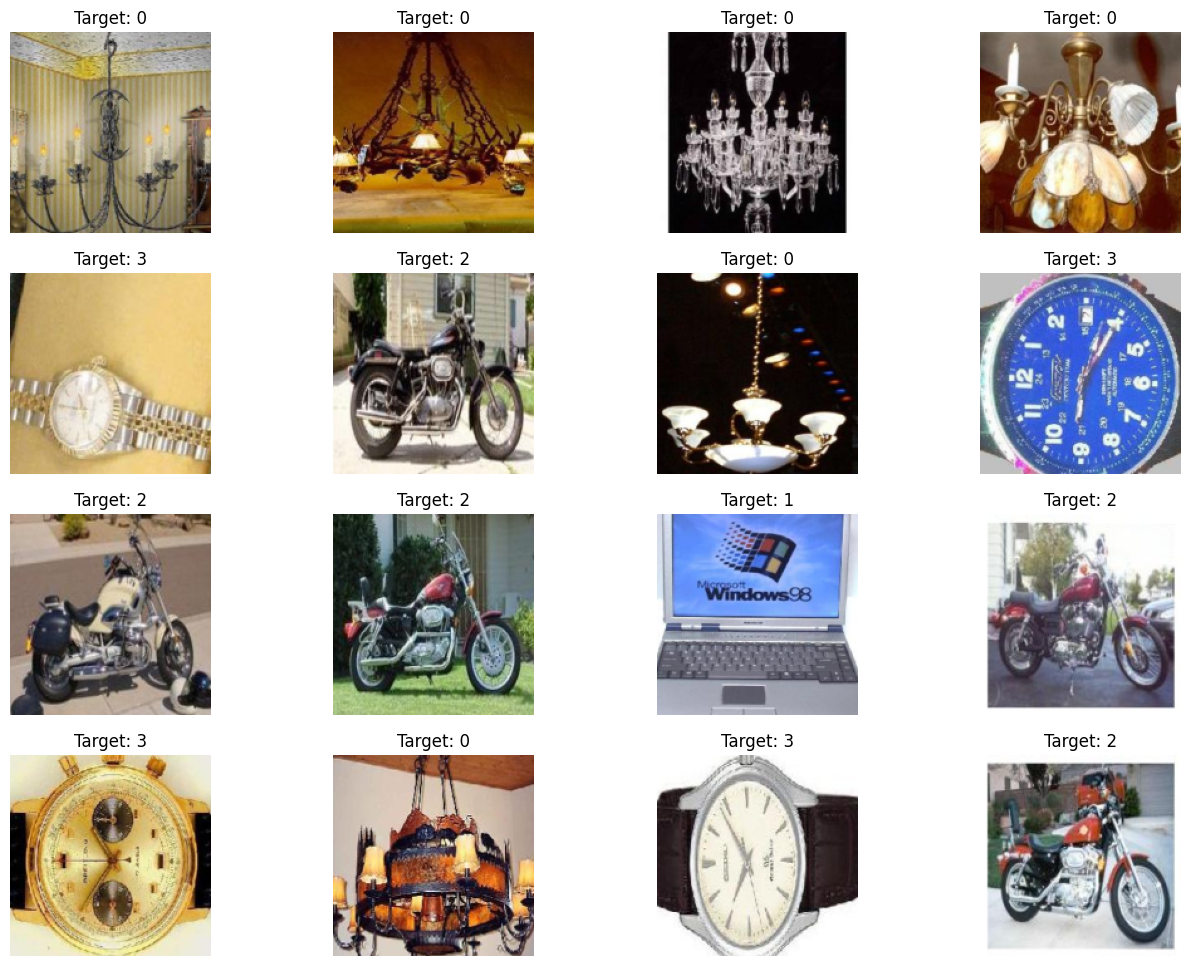

In [9]:
plt.rcParams["figure.figsize"] = (16, 12)
plt.figure
for images, labels in train_dataloader:
    for i in range(len(labels)):
        plt.subplot(4, 4, i + 1)
        img = transforms.functional.to_pil_image(images[i])
        plt.imshow(img)
        plt.axis("off")
        plt.gca().set_title("Target: {0}".format(labels[i]))
    plt.show()
    break

## Check Init Loss and Accuracy

Verify that the model was initialised randomly by verifying the loss and accuracy. 
The initial loss is expected to be around `ln(num_classes)` and the accuracy is about `1/num_classes`. 

In [10]:
from sklearn.metrics import accuracy_score


class CheckInitLossAndAccuracy:
    def __init__(self, net, x, num_classes, target=None):
        self.net = net
        self.x = x
        self.num_classes = num_classes
        self.criterion = nn.CrossEntropyLoss()
        self.batch_size = self.x.size()[0]

        if target is None:
            self.target = torch.randint(0, self.num_classes, size=(self.batch_size,))
        else:
            self.target = target

        self.logits = self.net(self.x)

    def verify_init_loss(self):
        loss = self.criterion(self.logits, self.target)
        print(f"Expected loss: {np.log(self.num_classes)}")
        print(f"Inferred loss: {loss.item()}")

    def verify_init_accuracy(self):
        predictions = torch.argmax(F.softmax(self.logits, dim=1), axis=1)
        accuracy = accuracy_score(self.target, predictions.detach())
        print(f"Expected accuracy: {1 / self.num_classes}")
        print(f"Inferred accuracy: {accuracy}")

In [11]:
num_classes = 4
print(f"Num of Classes: {num_classes}")

x, y = next(iter(train_dataloader))
model = Net(num_classes=num_classes)
checker = CheckInitLossAndAccuracy(net=model, x=x, num_classes=num_classes, target=y)
checker.verify_init_accuracy()
checker.verify_init_loss()

Num of Classes: 4
Expected accuracy: 0.25
Inferred accuracy: 0.1875
Expected loss: 1.3862943611198906
Inferred loss: 1.4033185243606567


## Does Loss go down at every epoch?

### Avg data in batch

In [12]:
import torch.optim as optim

num_classes = 4
model_avgBatch = Net(num_classes=num_classes)
criterion = nn.CrossEntropyLoss()
optimiser = optim.SGD(params=model_avgBatch.parameters(), lr=0.001, momentum=0.9)

loss_record = []
num_epochs = 10
for epoch in range(num_epochs):
    loss_per_epoch = 0.0
    for i, data in enumerate(train_dataloader):
        optimiser.zero_grad()
        x, y = data
        logits = model_avgBatch(x)
        loss = criterion(logits, y)

        loss_per_epoch += loss.item()
        loss.backward()
        optimiser.step()

    avg_loss = loss_per_epoch / (i + 1)
    loss_record.append(avg_loss)
    print("Loss at epoch {0} = {1}".format(epoch + 1, avg_loss))

Loss at epoch 1 = 1.393273467818896
Loss at epoch 2 = 1.3898802200953166
Loss at epoch 3 = 1.3883287260929744
Loss at epoch 4 = 1.3856160243352253
Loss at epoch 5 = 1.3838329712549846
Loss at epoch 6 = 1.3808773458003998
Loss at epoch 7 = 1.3793813685576122
Loss at epoch 8 = 1.3778014828761418
Loss at epoch 9 = 1.3766320198774338
Loss at epoch 10 = 1.3766591797272365


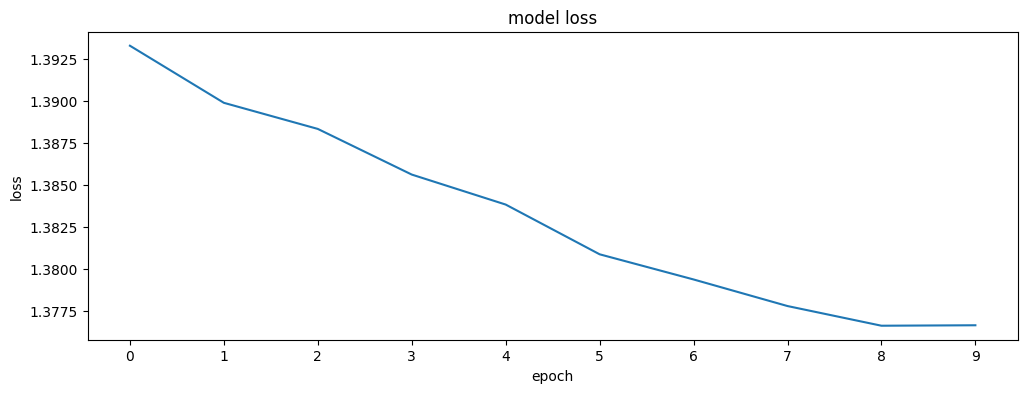

In [13]:
plt.figure(figsize=(12, 4))
plt.plot(loss_record)
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.xticks(np.arange(0, 10))
plt.show()

### Per batch

In [18]:
num_classes = 4
model_batch = Net(num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_batch.parameters(), lr=0.001)

x, target = next(iter(train_dataloader))
print(x.shape)

loss_record = []
num_iters = 25
for i in range(num_iters):
    optimizer.zero_grad()
    logits = model_batch(x)
    loss = criterion(logits, target)
    temp_loss = loss.item()
    loss.backward()
    optimizer.step()
    loss_record.append(temp_loss)
    print("Loss at iteration-{} is {}".format(i + 1, temp_loss))

torch.Size([16, 3, 160, 160])
Loss at iteration-1 is 1.3946975469589233
Loss at iteration-2 is 1.2893335819244385
Loss at iteration-3 is 1.2872668504714966
Loss at iteration-4 is 1.2051082849502563
Loss at iteration-5 is 1.2027413845062256
Loss at iteration-6 is 1.1568397283554077
Loss at iteration-7 is 1.0958608388900757
Loss at iteration-8 is 1.0116134881973267
Loss at iteration-9 is 0.8871208429336548
Loss at iteration-10 is 0.7669063806533813
Loss at iteration-11 is 0.613487184047699
Loss at iteration-12 is 0.4956854581832886
Loss at iteration-13 is 0.43442243337631226
Loss at iteration-14 is 0.5028781890869141
Loss at iteration-15 is 0.3992159962654114
Loss at iteration-16 is 0.425439715385437
Loss at iteration-17 is 0.170100137591362
Loss at iteration-18 is 0.27639439702033997
Loss at iteration-19 is 0.18501845002174377
Loss at iteration-20 is 0.108963742852211
Loss at iteration-21 is 0.12894463539123535
Loss at iteration-22 is 0.11897876113653183
Loss at iteration-23 is 0.079871

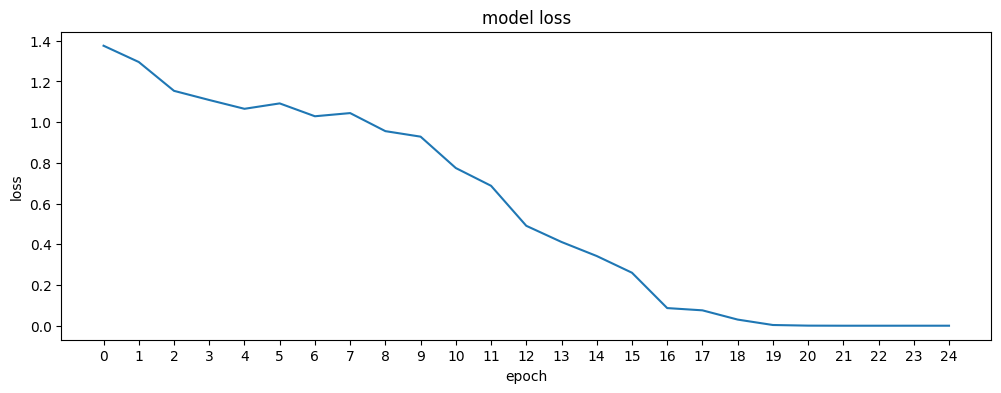

In [15]:
plt.figure(figsize=(12, 4))
plt.plot(loss_record)
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.xticks(np.arange(0, i + 1))
plt.show()

## Forward pass a Zero Input

Send a Tensor of zeros as input to the model and verify if the loss is high 

In [19]:
criterion = nn.CrossEntropyLoss()

x = torch.zeros(size=(16, 3, 160, 160))
target = torch.randint(0, 4, size=(16,))
logits = model_avgBatch(x)

loss = criterion(logits, target)
print("Loss with zero-valued input: ", loss.item())

Loss with zero-valued input:  1.3833122253417969


## Evaluate model on test dataset

In [20]:
num_classes = 4
model_evaluate = Net(num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_evaluate.parameters(), lr=0.001, momentum=0.9)


loss_list = []
num_epochs = 10
for epoch in range(num_epochs):
    per_epoch_loss = 0
    for i, data in enumerate(train_dataloader):
        optimizer.zero_grad()
        x, target = data
        model_evaluate.train()
        logits = model_evaluate(x)
        loss = criterion(logits, target)
        temp_loss = loss.item()
        per_epoch_loss += temp_loss
        loss.backward()
        optimizer.step()
    per_epoch_avg_loss = per_epoch_loss / (i + 1)
    loss_list.append(per_epoch_avg_loss)
    print("Traning loss at epoch {} = {}".format(epoch + 1, per_epoch_avg_loss))

    if (epoch + 1) % 2 == 0:
        total_test_loss = 0
        with torch.no_grad():
            model_evaluate.eval()
            for j, test_data in enumerate(test_dataloader):
                test_x, test_target = test_data
                test_logits = model_evaluate(test_x)
                test_loss = criterion(test_logits, test_target)
                total_test_loss += test_loss.item()
            print(
                "Test loss at epoch {} = {}".format(
                    epoch + 1, total_test_loss / (j + 1)
                )
            )

Traning loss at epoch 1 = 1.3817114929358165
Traning loss at epoch 2 = 1.3800806452830632
Test loss at epoch 2 = 1.378917932510376
Traning loss at epoch 3 = 1.379300167163213
Traning loss at epoch 4 = 1.3785703480243683
Test loss at epoch 4 = 1.374726802110672
Traning loss at epoch 5 = 1.3785807142655055
Traning loss at epoch 6 = 1.3770565390586853
Test loss at epoch 6 = 1.3720775246620178
Traning loss at epoch 7 = 1.3748843024174373
Traning loss at epoch 8 = 1.3747323503096898
Test loss at epoch 8 = 1.3699408769607544
Traning loss at epoch 9 = 1.3753059854110081
Traning loss at epoch 10 = 1.3747160484393437
Test loss at epoch 10 = 1.3673955798149109


## Check Dimensions using Backprop

1. Consider a simple network with just a few convolutional and linear layers, whose input shapeis `(1,28,28)` and output shape is `10`.
1. Take the batch size to be `25`. The input size will then be `(25,1,28,28)` and the output `25,10`.
1. Plug the output in the Loss function. The loss output is just one number, a scalar, which is either summed or averaged over the `25` loss values. However, you can get the unsummed and unaveraged loss-values, by passing `reduciton='none'`, when instantiating `nn.CrossEntropyLoss()`. Now, if we evaluate the loss, it would not be scalar, but a vector of `25` entries, where each entry corresponds to the loss for each image in the batch. 
1. As discussed in the video, keep only one entry in this `25-d` loss-vector intact. Set the remaining `24` entries to zero. The calculate the gradients via backpropagation from this modified loss. 
1. After backpropagation, its gradients can be accessed. A this point, note that the gradients should be of size `(25, num_weights)`. Each entry in the first dimension must correspond to the gradients for each image. 

We claimed that if the dimensions are right, then all the gradients, except that in the `11th` entry will be zero.  No need to check   the entries for this.  Just sum up the gradients along the batch (first) dimension, and look at the resulting `25` numbers. You will see  that the index with the highest number is `11`, indicating that the gradients at the `11th` entry are non-zero.


If the dimensions are not right, then the index will not be 11.

In [24]:
class CheckDimsViaBackprop:
    def __init__(
        self, net_class, x, num_classes, target=None, selected_sample_index=11
    ):
        self.first_model = None
        self.net_class = net_class
        self.x = x
        self.num_classes = num_classes
        self.batch_size = self.x.size()[0]
        self.selected_sample_index = selected_sample_index

        if target is None:
            self.target = torch.randint(0, self.num_classes, size=(self.batch_size,))
        else:
            self.target = target

    def get_batched_gradients_metric(self):
        first_model = self.net_class(self.num_classes)
        self.first_model = first_model
        criterion = nn.CrossEntropyLoss(reduction="none")

        logits = first_model(self.x)
        loss = criterion(logits, self.target)

        mask = torch.zeros_like(loss)
        mask[self.selected_sample_index] = 1
        loss *= mask
        loss = loss.sum()
        loss.backward()

        grad_metric = abs(
            sum([p.grad.numpy().sum() for p in list(first_model.parameters())])
        )
        print("Batched Gradient Metric: ", grad_metric)
        return None

    def get_individual_gradients_metric(self):
        second_model = self.net_class(self.num_classes)
        second_model.load_state_dict(self.first_model.state_dict())

        criterion = nn.CrossEntropyLoss(reduction="none")
        logits = second_model(self.x)
        loss = criterion(logits, self.target)

        mask = torch.zeros_like(loss)
        mask[self.selected_sample_index] = 1
        loss *= mask
        temp_loss = loss.clone()

        for i in range(len(temp_loss)):
            second_model.zero_grad()
            temp_img = self.x[i, ...]
            op = second_model(torch.unsqueeze(temp_img, 0))
            temp_target = torch.Tensor([self.target[i]]).long()
            loss = criterion(op, temp_target)
            loss = temp_loss[i]
            loss.backward(retain_graph=True)
            grads = [p.grad.numpy().sum() for p in list(second_model.parameters())]
            grad_metric = abs(sum(grads))
            if grad_metric > 0:
                print("Gradient metric at sample {} =  ".format(i), grad_metric)
        return None

In [25]:
num_classes = 4

x, target = next(iter(train_dataloader))


selected_sample_index = 11
check2 = CheckDimsViaBackprop(
    Net, x, num_classes, target, selected_sample_index
)  # NOTE - this will expect
# the nn.Module class,
# not the nn.Module object..!!
assert selected_sample_index < x.size()[0]

check2.get_batched_gradients_metric()
check2.get_individual_gradients_metric()

Batched Gradient Metric:  74.64797
Gradient metric at sample 11 =   74.64797
